In [1]:
import sys
sys.path.append('../../')
import sophi_fdt_dpp as fdt
import matplotlib.pyplot as plt
import numpy as np

sophi_fdt_dpp version Cavity_update_artem2 (final_calibration_brunch_reordering@76019f1)
error importing photoutils, CircularAperture is used in PHI_shifts_FFT / aperture


In [2]:
data_dir = 'test_data/level2/'
list_of_files = fdt.list_fits(inpath = data_dir,contain='stokes',remove_dir=True)
stokes,header = fdt.fits_get(data_dir+list_of_files[0],scale=False)

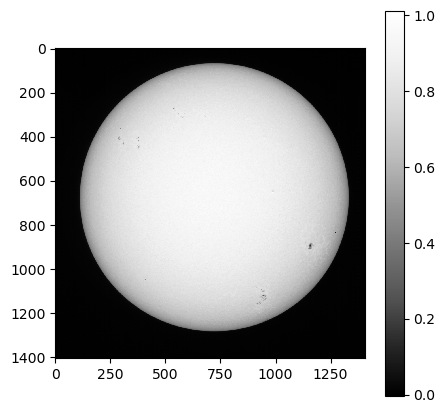

In [3]:
plt.imshow(stokes[0,0,:,:],cmap='Greys_r')
plt.colorbar()

### Extract wavelength axis from header

Extract the wavelength axis from the header using: ` fits_get_sampling() `

In [4]:
stokes.shape

(6, 4, 1408, 1408)

In [5]:
wave_axis, voltagesData, PHI_FG_setWavelength, tunning_constant, cpos, ref_wavelength = fdt.fits_get_sampling(data_dir+list_of_files[0])

print('wave_axis (angstrom)= ', wave_axis)
print('wave_axis (volts) = ', voltagesData)
print('tunning_constant (A/V)= ', tunning_constant)
print('tunning_constant (V/A)= ', 1./tunning_constant)
print('Continuum position = ', 'red' if cpos[0] == 0 else 'blue')
print('reference wavelength = ', ref_wavelength)
print(wave_axis-ref_wavelength)

-- Obtaining sampling information from......test_data/level2/solo_L2_phi-fdt-stokes_20240319T152009_V202602220014_0443190639.fits.gz
-- Only works for nominal six wavelength scan data. Line scan and PD are not supported yet.
continuum was taken in the RED and stored in the RED
wave_axis (angstrom)=  [6172.90169935 6172.9714324  6173.0402872  6173.1101959  6173.1801046
 6173.33766265]
wave_axis (volts) =  [-1250.5 -1052.   -856.   -657.   -458.     -9.5]
tunning_constant (A/V)=  0.0003513
tunning_constant (V/A)=  2846.569883290635
Continuum position =  blue
reference wavelength =  6173.341
[-0.43930065 -0.3695676  -0.3007128  -0.2308041  -0.1608954  -0.00333735]


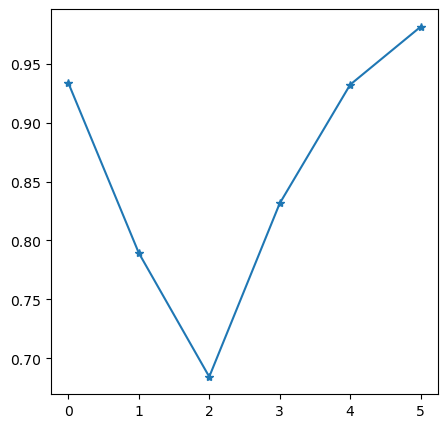

In [6]:
plt.plot(stokes[:,0,750,750],'-*')

In [7]:
rte_mode = 'CE'
#this is the most basic form
init_model = np.array([100,20,150,5,0.09,0.13,.01,.3,.7])
weight = np.array([1.,4.,5.4,4.1])
ce = fdt.generate_level2(stokes,header,wave_axis,rte_mode,initial_model = init_model)

Centering...
   It is assumed the wavelength is given by the header info 
         wave axis:  [6173.20241215 6173.2721452  6173.341      6173.4109087  6173.4808174
 6173.63837545]
         wave axis (step):   [-138.58785  -68.8548     0.        69.9087   139.8174   297.37545]
         reference wavelength:   6173.341
No input options. Setting for PHI only.
Using defaults weights: [ 1. 10. 10.  4.]
Using init model: [1.0e+02 2.0e+01 1.5e+02 5.0e+00 9.0e-02 1.3e-01 1.0e-02 3.0e-01 7.0e-01]
RTE_MODE  CE
options:  [6, 30, 2, 0, 0, 0, 0, 0, 0]
Using PMILOS version
   input shape in phi_rte:  (6, 4, 1408, 1408)
   reshaping into:  (6, 4, 1982464)
   reshaping data. New data shape (1982464, 4, 6) should be (y * x,pol,wave) for C
Entering pmilos


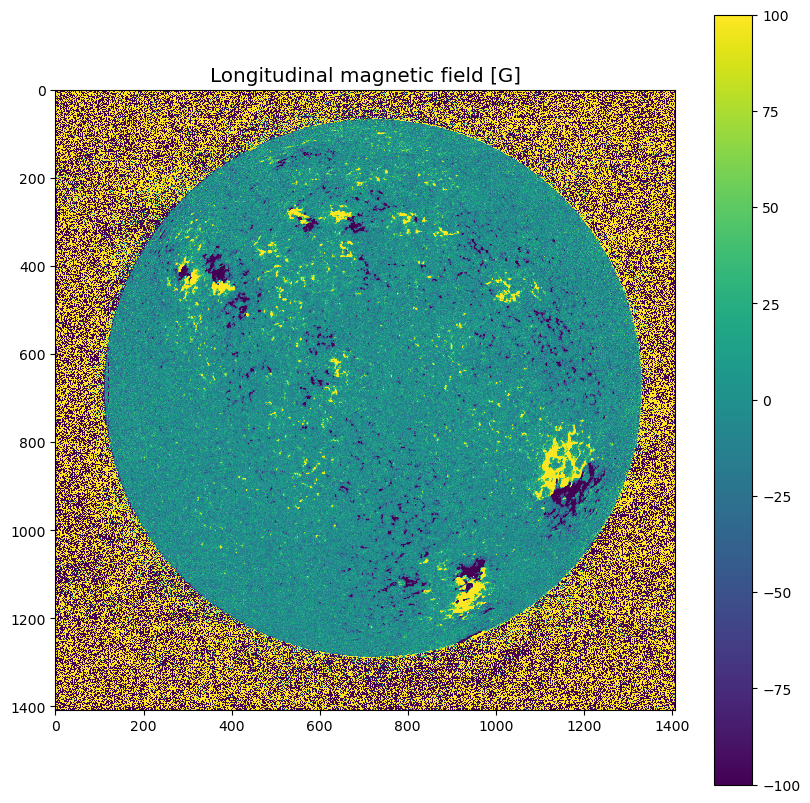

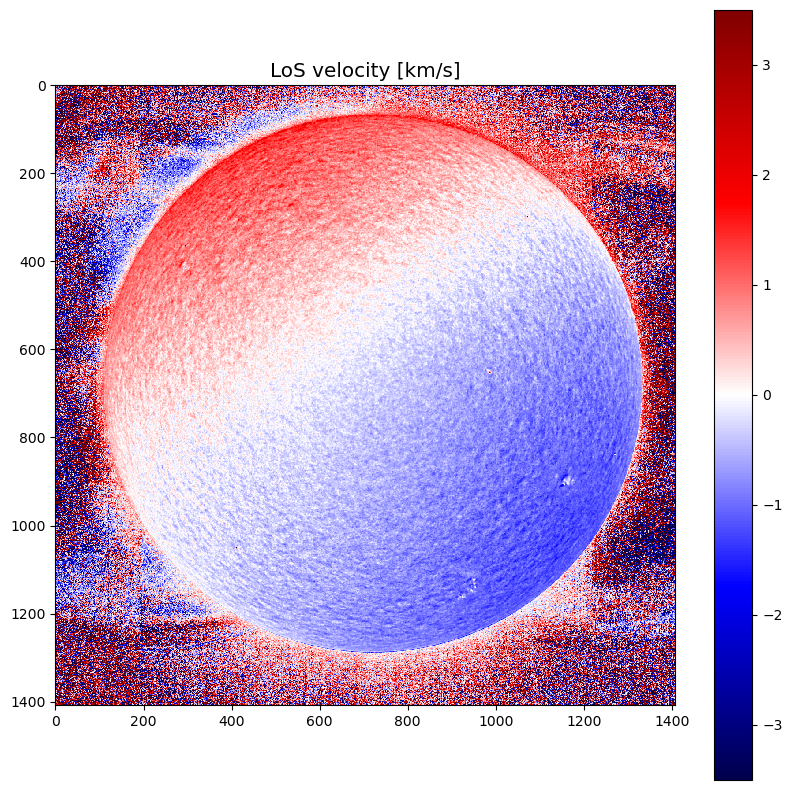

In [8]:
plt.figure(figsize=(10,10))
plt.imshow(ce[2,:,:]*np.cos(ce[3,:,:]*np.pi/180.),vmin=-100,vmax=100)
plt.title('Longitudinal magnetic field [G]')
plt.colorbar()
plt.show()

plt.figure(figsize=(10,10))
plt.imshow(ce[8,:,:],vmin=-3.5,vmax=3.5,cmap='seismic')
plt.title('LoS velocity [km/s]')
plt.colorbar()
plt.show()

In [9]:
from scipy.signal import fftconvolve

def moffat_psf(size, alpha, beta):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    r2 = xx**2 + yy**2

    psf = (1 + (r2 / alpha**2))**(-beta)
    psf /= psf.sum()
    return psf


from scipy.ndimage import center_of_mass, gaussian_filter

def azimuthal_average(image, center):
    y, x = np.indices(image.shape)
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)

    r_int = r.astype(int)

    tbin = np.bincount(r_int.ravel(), image.ravel())
    nr = np.bincount(r_int.ravel())

    radial_profile = tbin / np.maximum(nr, 1)

    radius = np.arange(len(radial_profile))

    return radial_profile, radius

def detect_disk(image, smooth_sigma=2):
    p_low = np.percentile(image, 5)
    p_high = np.percentile(image, 95)

    background = p_low
    image_corr = image - background
    image_corr[image_corr < 0] = 0
    if p_high > p_low:
        image_corr /= (p_high - p_low)
    image_smooth = gaussian_filter(image_corr, sigma=smooth_sigma)
    cy, cx = center_of_mass(image_smooth)
    y, x = np.indices(image.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)
    gy, gx = np.gradient(image_smooth)
    grad = np.sqrt(gx**2 + gy**2)
    prof_grad, r_arr = azimuthal_average(grad, (cy, cx))

    R = r_arr[np.argmax(prof_grad)]

    i_peak = np.argmax(prof_grad)

    if 1 < i_peak < len(prof_grad) - 2:
        y0 = prof_grad[i_peak-1:i_peak+2]
        x0 = r_arr[i_peak-1:i_peak+2]

        # ajuste parabólico simple
        try:
            coeff = np.polyfit(x0, y0, 2)
            R = -coeff[1] / (2 * coeff[0])
        except:
            pass

    return (cy, cx, R)

def estimate_epsilon(image, target_contrast=0.15, mask_radius_factor=0.3, epsilon = 0):
    cy, cx, radius = detect_disk(image)

    y, x = np.indices(image.shape)
    r = np.sqrt((x - cx)**2 + (y - cy)**2)

    mask = r <= (mask_radius_factor * radius)

    Iq = image[mask]
    contrast = np.std(Iq) / np.mean(Iq)

    if epsilon == 0:
        eps = max(0, 1 - contrast / target_contrast)
    else:
        eps = epsilon

    return np.clip(eps, 0.01, 0.4), mask

def correct_straylight(data,
                    psf_size=31,
                    alpha=4.0,
                    beta=2.5,
                    n_iter=2,
                    target_contrast=0.15,
                    epsilon = 0.10,
                    mask_radius_factor=0.3,
                    wave_ref=0):

    """
    Wavelength-independent stray light correction

    Parameters
    ----------
    alpha, beta : PSF parameters (fixed)
    epsilon     : estimated once from a reference wavelength if epsilon == 0. If not, just take the value.

    alpha ≈ 3 – 6 pixels
    beta  ≈ 2 – 3
    epsilon ≈ 0.05 – 0.20

    """

    nw, ns, nx, ny = data.shape

    # --- Estimate epsilon ONLY ONCE ---
    epsilon, mask = estimate_epsilon(
        data[wave_ref, 0],
        target_contrast=target_contrast,
        epsilon = epsilon,
        mask_radius_factor=mask_radius_factor
    )

    # --- Single PSF ---
    psf = moffat_psf(psf_size, alpha, beta)

    corrected = data.copy()

    for _ in range(n_iter):
        for w in range(nw):
            for s in range(ns):
                img = corrected[w, s]

                blurred = fftconvolve(img, psf, mode='same')

                corrected[w, s] = img - epsilon * (blurred - img)

    return corrected, psf, mask



In [10]:
corrected, psf, mask = correct_straylight(stokes,
                psf_size=31,
                alpha=4.0,
                beta=2.5,
                n_iter=2,
                target_contrast=0.08,
                epsilon = 0.15,
                mask_radius_factor=0.3,
                wave_ref=-1,
)


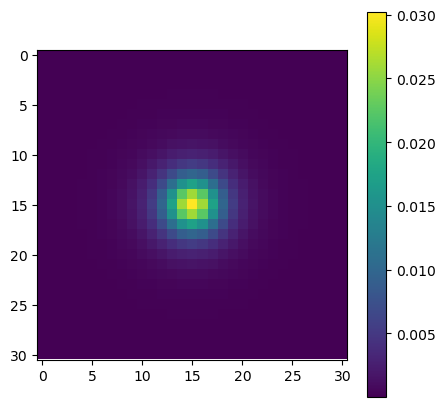

In [11]:
plt.imshow(psf)
plt.colorbar()

In [12]:
ce2 = fdt.generate_level2(corrected,header,wave_axis,rte_mode,initial_model = init_model)


Centering...
   It is assumed the wavelength is given by the header info 
         wave axis:  [6173.20241215 6173.2721452  6173.341      6173.4109087  6173.4808174
 6173.63837545]
         wave axis (step):   [-138.58785  -68.8548     0.        69.9087   139.8174   297.37545]
         reference wavelength:   6173.341
No input options. Setting for PHI only.
Using defaults weights: [ 1. 10. 10.  4.]
Using init model: [1.0e+02 2.0e+01 1.5e+02 5.0e+00 9.0e-02 1.3e-01 1.0e-02 3.0e-01 7.0e-01]
RTE_MODE  CE
options:  [6, 30, 2, 0, 0, 0, 0, 0, 0]
Using PMILOS version
   input shape in phi_rte:  (6, 4, 1408, 1408)
   reshaping into:  (6, 4, 1982464)
   reshaping data. New data shape (1982464, 4, 6) should be (y * x,pol,wave) for C
Entering pmilos


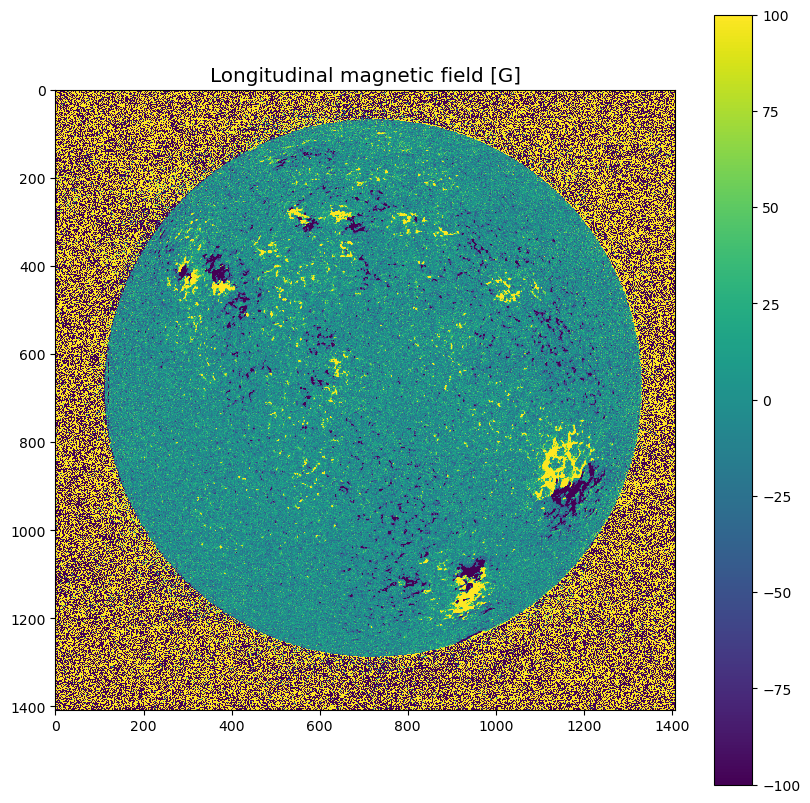

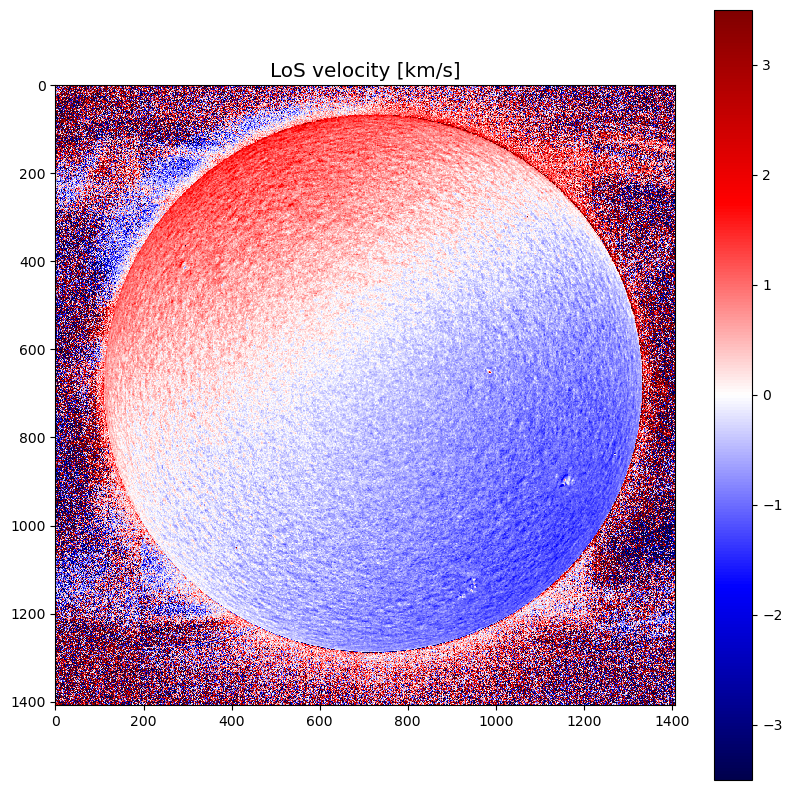

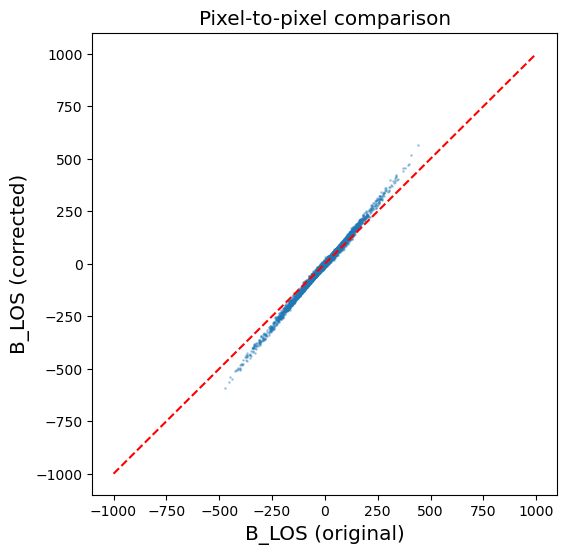

Mean difference: -0.7615223602162887
Std difference : 979.986083675492


In [14]:
plt.figure(figsize=(10,10))
plt.imshow(ce2[2,:,:]*np.cos(ce2[3,:,:]*np.pi/180.),vmin=-100,vmax=100)
plt.title('Longitudinal magnetic field [G]')
plt.colorbar()
plt.show()

plt.figure(figsize=(10,10))
plt.imshow(ce2[8,:,:],vmin=-3.5,vmax=3.5,cmap='seismic')
plt.title('LoS velocity [km/s]')
plt.colorbar()
plt.show()

b1 = ce[2,:,:]*np.cos(np.deg2rad(ce[3,:,:]))
b2 = ce2[2,:,:]*np.cos(np.deg2rad(ce2[3,:,:]))

plt.figure(figsize=(6,6))
plt.scatter(b1[mask].flatten(), b2[mask].flatten(), s=1, alpha=0.3)

plt.xlabel('B_LOS (original)')
plt.ylabel('B_LOS (corrected)')
plt.title('Pixel-to-pixel comparison')

# Línea ideal
lims = [-1000, 1000]
plt.plot(lims, lims, 'r--')

plt.show()

diff = b1 - b2

print("Mean difference:", np.mean(diff))
print("Std difference :", np.std(diff))